# Machine Learning Foundations: Multiple Linear Regression

**Summary**
This notebook extends the concepts of linear regression to multiple input features, demonstrating how to implement gradient descent for multivariate data through vectorization.

**Key Takeaways:**

1.  **Multiple Features**: Transitioning from a single variable to a feature vector $\vec{x}$ (e.g., size, bedrooms, floors, age).
2.  **Vectorization**: Using `np.dot` to efficiently compute predictions $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$, which replaces manual loops and improves performance.
3.  **Multivariate Cost Function**: Adapting the squared error cost function to handle matrices of training examples and weight vectors.
4.  **Gradient Descent for Multiple Variables**: Implementing the simultaneous update rule for each weight $w_j$ based on its specific partial derivative.
5.  **Feature Scaling (Z-score Normalization)**: Essential preprocessing step to center features ($\mu=0, \sigma=1$), ensuring Gradient Descent converges quickly despite different data scales (e.g., thousands of sqft vs. units of bedrooms).
6.  **Scaling & Learning Rates**: Observing the behavior of cost reduction over time and the importance of choosing an appropriate learning rate $\alpha$ for data with multiple features.

---


Simple gradient descent for linear regression


In [88]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.set_printoptions(precision=2)

Synthetic dataset containing 10,000 housing records with physical features (size, bedrooms, floors, age) and calculated prices for linear regression testing.


In [89]:
data = pd.read_csv(
    '../../../data/foundations/machine learning foundations/houses_data.csv')

X_train = data.iloc[:, :4].to_numpy()
y_train = data.iloc[:, 4].to_numpy()

data

,size_sqft,bedrooms,floors,age,price_1000s
0,2028,3,2,29,449.40
1,2596,2,2,33,459.22
2,1720,2,1,1,448.85
3,1838,2,1,56,327.82
4,1723,3,1,26,349.09
...,...,...,...,...,...
9995,1536,2,2,37,336.11
9996,2102,3,2,24,461.00
9997,1632,4,1,8,435.10
9998,2523,5,1,5,596.20


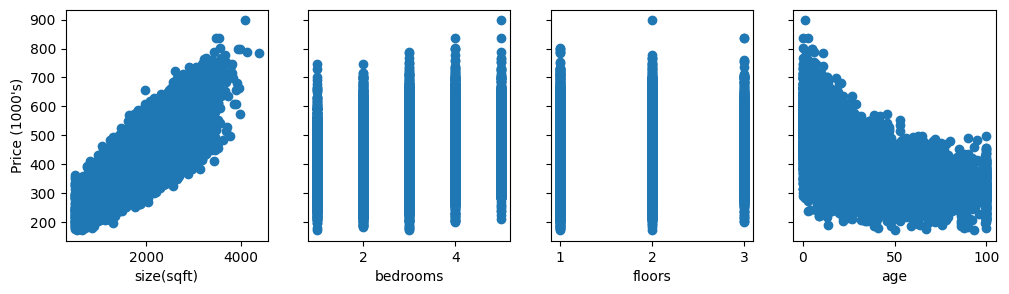

In [90]:
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

Performing feature scaling to improve gradient descent performance.
Implementing z-score normalization on features (Size and Bedrooms).


In [ ]:
def zscore_normalize_features(X):
    """
    computes  X, zcore normalized by column

    Args:
      X (ndarray (m,n))     : input data, m examples, n features

    Returns:
      X_norm (ndarray (m,n)): input normalized by column
      mu (ndarray (n,))     : mean of each feature
      sigma (ndarray (n,))  : standard deviation of each feature
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma  # NOSONAR

    return (X_norm, mu, sigma)

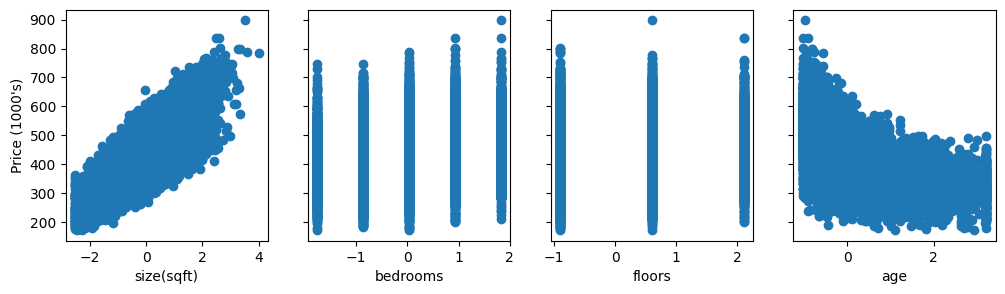

In [92]:
X_normalized, X_mean, X_std = zscore_normalize_features(X_train)

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_normalized[:, i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

In [ ]:
from scipy.stats import norm


def norm_plot(ax, data):
    scale = (np.max(data) - np.min(data))*0.2
    x = np.linspace(np.min(data)-scale, np.max(data)+scale, 50)
    _, bins, _ = ax.hist(data, x, color="xkcd:azure")
    # ax.set_ylabel("Count")

    mu = np.mean(data)
    std = np.std(data)
    dist = norm.pdf(bins, loc=mu, scale=std)

    axr = ax.twinx()
    axr.plot(bins, dist, color="orangered", lw=2)
    axr.set_ylim(bottom=0)
    axr.axis('off')

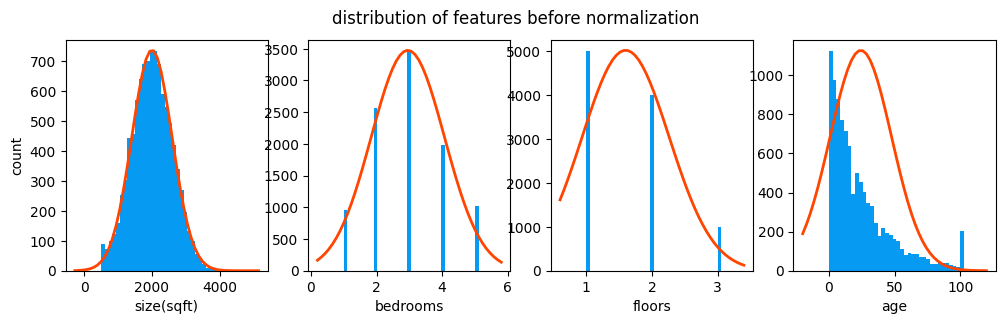

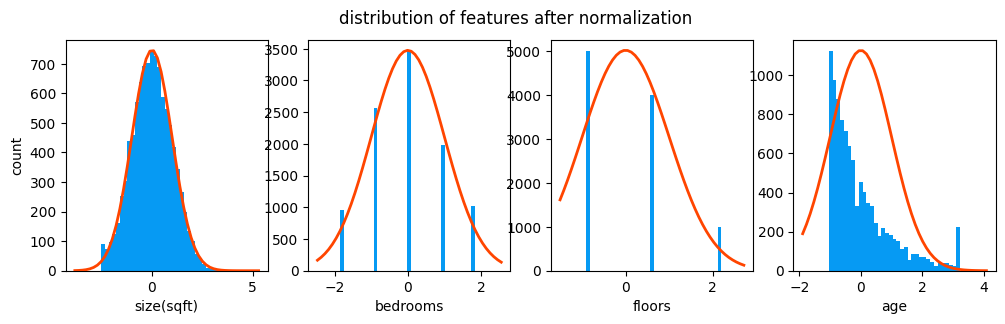

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    norm_plot(ax[i], X_train[:, i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count")
fig.suptitle("distribution of features before normalization")
plt.show()
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    norm_plot(ax[i], X_normalized[:, i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count")
fig.suptitle("distribution of features after normalization")

plt.show()

In [ ]:
def predict_one_value_with_normalization(x, w, b, X_mean, X_std):  # NOSONAR
    """
    Computes the prediction of linear model

    Args:
        x (ndarray): Input values
        w (ndarray): Weights
        b (float): Bias
        X_mean (ndarray): Mean of features
        X_std (ndarray): Standard deviation of features
    Returns:
        float: Prediction
    """
    x = (x - X_mean) / X_std
    return np.dot(x, w) + b


def predict_one_value_without_normalization(x, w, b):
    """
    Computes the prediction of linear model

    Args:
        x (ndarray): Input values
        w (ndarray): Weights
        b (float): Bias
    Returns:
        float: Prediction
    """
    return np.dot(x, w) + b

In [112]:
def compute_cost(X, y, w, b):
    """Computes the cost over all examples
    Args:
      x (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters
      b (scalar)       : model parameter
    Returns
      cost (scalar): cost
    """

    m, n = X.shape
    cost = 0.0
    for i in range(m):
        f_wb = predict_one_value_without_normalization(X[i], w, b)
        cost = cost + (f_wb - y[i]) ** 2

    cost = cost / (2 * m)
    return cost

In [113]:
def compute_gradient(X, y, w, b):
    """Computes the gradient for linear regression with multiple variables
    Args:
      X (ndarray (m,n)): Data, m examples
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters
      b (scalar): model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
    """

    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = predict_one_value_without_normalization(X[i], w, b)
        error = f_wb - y[i]
        for j in range(n):
            dj_dw[j] += error * X[i, j]
        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

Gradient Descent Algorithm


In [114]:
def gradient_descent(X, y, w_initial, b_initial, learning_rate, num_iterations, cost_function, gradient_function):

    w = w_initial
    b = b_initial

    # Number of training examples
    m, n = X.shape

    cost_history = []
    param_history = []

    for i in range(num_iterations):
        # Computing gradient
        dj_dw, dj_db = gradient_function(X, y, w, b)

        # Updating parameters
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        # Computing cost
        cost = cost_function(X, y, w, b)

        # Storing history
        cost_history.append(cost)
        param_history.append((w, b))

        # Printing cost every 50 iterations
        if i % 100 == 0:
            print(f"Iteration {i:4}: Cost = {cost:0.2e}")

    return w, b, cost_history, param_history

In [115]:
# Initializing parameters
w_initial = np.zeros((X_train_data.shape[1],))
b_initial = 0.0

learning_rate = 1e-1
num_iterations = 1000

w_final, b_final, cost_history, param_history = gradient_descent(
    X_normalized, y_train, w_initial, b_initial, learning_rate, num_iterations, compute_cost, compute_gradient)

print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")

Iteration    0: Cost = 8.18e+04
Iteration  100: Cost = 5.24e+02
Iteration  200: Cost = 5.24e+02
Iteration  300: Cost = 5.24e+02
Iteration  400: Cost = 5.24e+02
Iteration  500: Cost = 5.24e+02
Iteration  600: Cost = 5.24e+02
Iteration  700: Cost = 5.24e+02
Iteration  800: Cost = 5.24e+02
Iteration  900: Cost = 5.24e+02
b,w found by gradient descent: 437.75,[ 73.15  18.37   8.12 -55.54] 


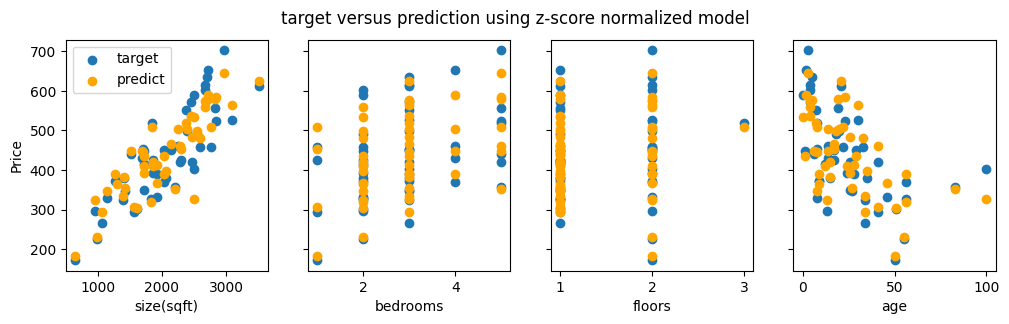

In [ ]:
m_to_use = 50
yp = np.zeros(m_to_use)
for i in range(m_to_use):
    yp[i] = np.dot(X_normalized[i], w_final) + b_final

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:m_to_use, i], y_train[:m_to_use], label='target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:m_to_use, i], yp[:m_to_use],
                  color="orange", label='predict')
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

In [ ]:
x_house = np.array([3100, 4, 2, 2])
prediction = predict_one_value_with_normalization(
    x_house, w_final, b_final, X_mean, X_std)

print(f"Prediction for a 3,100 sqft house, 2 years old: ${prediction:0.2f}k")
print("Expected target value: ~$655.00k")

Prediction for a 3,100 sqft house, 2 years old: $648.51k
Expected target value: ~$655.00k
